#run this command as needed to re-establish connection to Big Query
gcloud auth login --update-adc

In [ ]:
# %%capture
!pip install xgboost
!pip install imbalanced-learn
!pip install catboost
!pip install optuna
import pandas as pd
import numpy as np
import time
from google.cloud import bigquery
from xgboost import XGBClassifier
import catboost
from catboost import CatBoostClassifier, Pool, metrics, cv
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, KFold
from sklearn.metrics import f1_score, make_scorer, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV
import random
import torch
import optuna

random.seed(100)
np.random.seed(100)

client = bigquery.Client()

def lift_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    top_indices = np.argsort(y_scores)[-top_1_percent:]
    actual_positives = y_true.iloc[top_indices].sum()
    expected_positives = y_true.sum() * 0.01
    lift = actual_positives / expected_positives if expected_positives != 0 else 0
    return lift

def true_positives_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    top_indices = np.argsort(y_scores)[-top_1_percent:]
    actual_positives = y_true.iloc[top_indices].sum()
    return actual_positives

def num_samples_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    return top_1_percent

def f1_score_top_1_percent(y_true, y_pred_proba):
    top_1_percent = int(0.01 * len(y_true))
    top_indices = np.argsort(y_pred_proba)[-top_1_percent:]
    y_true_top = y_true.iloc[top_indices]
    y_pred_top = np.ones(top_1_percent)
    return f1_score(y_true_top, y_pred_top)


# Make scorers
scorers = {
    'lift@1%': make_scorer(lift_at_1_percent, needs_proba=True),
    'f1@1%': make_scorer(f1_score_top_1_percent, needs_proba=True),
    'true_positives@1%': make_scorer(true_positives_at_1_percent, needs_proba=True),
    'num_samples@1%': make_scorer(num_samples_at_1_percent, needs_proba=True),
    'AUC':'roc_auc',
    'weighted AUC':make_scorer(roc_auc_score, needs_proba = True, multi_class = 'ovr', average = 'weighted') 
}

In [2]:
# Get features
sql = """
SELECT
    f.* EXCEPT (asdb_plan_key, post_mnths, first_prv_dt, last_prv_dt, index_dt)
    , e.* EXCEPT (individual_id)
FROM 
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_non_embedding_features` AS f
LEFT JOIN
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_embeddings` AS e
        ON f.asdb_member_key = e.individual_id
WHERE 1=1
    AND NOT asdb_plan_key IN (33, 54)
    AND post_mnths >= 6
    
"""
df_og = client.query(sql).to_dataframe() 

df_og.shape
#2,542,308 members who qualify with 564 features we are exploring

(2542308, 561)

In [3]:
# Get labels (acute IP) stay (0=no, 1=yes) in the 6 months post-index date
sql = """
SELECT
    asdb_member_key
    , acute_ip_flag
FROM 
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_outcome_ip` AS o
WHERE 1=1 
  AND o.asdb_member_key IN (SELECT asdb_member_key FROM `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_non_embedding_features` WHERE 1=1 AND NOT asdb_plan_key IN (33, 54) AND post_mnths >= 6)"""
outcome_og = client.query(sql).to_dataframe() 
outcome_og.shape

(2542308, 2)

In [4]:
from pandas.api.types import is_integer_dtype as is_integer
from pandas.api.types import is_float_dtype as is_float
import re

emb_pattern = r'emb[0-255]+'
emb_col = [col for col in df_og.columns if re.match(emb_pattern ,col)]
df_og[emb_col] = df_og[emb_col].fillna(0)

# TODO: HOW TO DEAL WITH NAs, tentatively fill with 0s
        
# print(df.dtypes)
for c in df_og.columns: 
    dt = df_og[c].dtype
    if is_integer(dt) or is_float(dt):
        df_og[c]=df_og[c].fillna(0) 
        # print("Floatint:", dt)
    else:
        try:
            df_og[c]= df_og[c].fillna('')
        except:
            print("ERROR - DATE VARIABLE FOUND", dt)

In [5]:
df = df_og
outcome = outcome_og


# COMMENT OUT WHEN TESTING WITH SUBSET
# _, df, _, outcome = train_test_split(df_og, outcome_og, test_size=0.01, random_state=100) # Sample small subset of data for testing purposes


df.shape
outcome.shape

(2542308, 2)

In [6]:
df = df.set_index('asdb_member_key')
outcome = outcome.set_index('asdb_member_key')
#merge outcome and features on asdb_member_key so we don't have label/predictors from different members
merged = df.merge(outcome, on='asdb_member_key', how='left')

assert merged.shape[1] == 561, "The number of columns in the DataFrame does not match expected feature + label count" # Splitting the data into train and test sets X_train, X_test, y_train, y_test = train_test_split( merged.iloc[:, :560], # Selecting first 560 columns as features, adjust if column count changes merged['acute_ip_flag'], # Using direct column selection for clarity test_size=0.2, random_state=100 )


In [73]:
# X_train, X_test, y_train, y_test = train_test_split(df, outcome, test_size=0.2, random_state=100) 

# stratified split to preserve ratio
X_train, X_test, y_train, y_test = train_test_split(merged.iloc[:, 1:560], merged.loc[:, 'acute_ip_flag'], test_size=0.2, random_state=100, stratify=merged.loc[:, 'acute_ip_flag'])
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=100, stratify=y_test)

# 80:10:10 split

In [80]:
def check_label_distribution(y):
    # Count the number of occurrences of each label 
    count_0 = (y == 0).sum()
    count_1 = (y == 1).sum()
    ratio = count_1 / count_0 if count_0 != 0 else np.inf
    print(count_0, count_1, ratio)
    return count_0, count_1, ratio

print("Training Set:")
check_label_distribution(y_train)

print("\nValidation Set:")
check_label_distribution(y_val)

print("\nTest Set:")
check_label_distribution(y_test)


Training Set:
1998976 34870 0.017443931292821926

Validation Set:
249872 4359 0.017444931805084204

Test Set:
249872 4359 0.017444931805084204


(249872, 4359, 0.017444931805084204)

y ratio: 0.171458 %


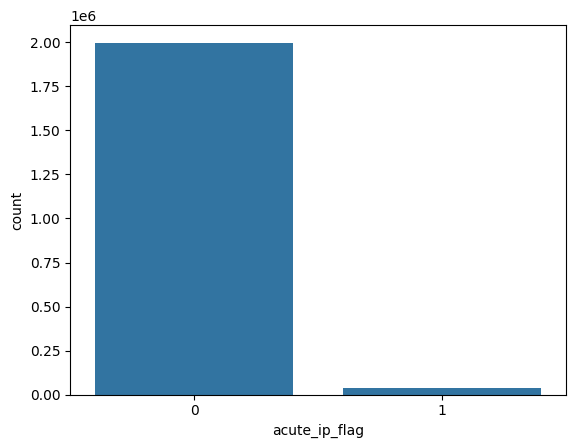

In [74]:
y_test.shape
sns.countplot(x=y_train)
ratio = round(y_test == 1).sum() / len(df) * 100
print('y ratio: %f %%'  %ratio)
# print('Bankruptcy count: %d'  %(y_train == 1).sum()) 1).sum()

In [78]:
string_columns = X_train.select_dtypes(include='object').columns.tolist() # CatBoost handles categorical features natively, thus we need to specify categorical columns
# TODO: Should this include just string features or all categorical features?

In [79]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for col in string_columns:
    X_train[col] = label_encoder.fit_transform(X_train[col])
    X_val[col] = label_encoder.fit_transform(X_val[col])
    X_test[col] = label_encoder.fit_transform(X_test[col])
    # print(col)

# Convert labels format
y_train = y_train.astype('int')
y_val = y_val.astype('int')
y_test = y_test.astype('int')


In [ ]:
# MAY NOT NEED IF CATBOOST ALREADY DEALS WITH IMBALANCE
# oversample = SMOTE(sampling_strategy=0.1, random_state=100)  
# undersample = RandomUnderSampler(sampling_strategy=0.5, random_state=100)  # Adjust ratio as needed

# steps = [
#     # ('o', oversample),
#     ('u', undersample)
# ]
# pipeline = Pipeline(steps=steps)

# X_train, y_train = pipeline.fit_resample(X_train, y_train)

In [ ]:
# Calculate class weights
class_weights = {
    0: 1,  #  majority class is 0
    1: (len(y_train) / (2 * y_train.sum()))  # Weight for the minority class
}

catboost_model_rfe = CatBoostClassifier(
    random_seed=100,
    thread_count=15,
    verbose=0,
    class_weights=class_weights
)

rfecv = RFECV(
    estimator=catboost_model_rfe,q
    step=10, # Num features removed for each step
    cv=KFold(2), # Num folds
    scoring="roc_auc",
    min_features_to_select=1,
    # n_jobs=2,
)

# with suppress_stdout_stderr():
rfecv.fit(X_train, y_train)

print(f"Optimal number of features: {rfecv.n_features_}")
# print(f"Feature rankings: {rfecv.ranking_}")


X_train_rfe = rfecv.transform(X_train) 
X_val_rfe = rfecv.transform(X_val) 
X_test_rfe = rfecv.transform(X_test)

In [ ]:
# Visualize RFE
n_features = list(range(1, len(rfecv.cv_results_['mean_test_score']) + 1))
mean_test_scores = rfecv.cv_results_['mean_test_score']

cv_results = pd.DataFrame({
    'n_features': n_features,
    'mean_test_score': mean_test_scores
})

plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.plot(cv_results["n_features"], cv_results["mean_test_score"])
plt.title("Recursive Feature Elimination \nwith correlated features")
plt.show()


# TODO: GET LIST OF FEATURES

In [ ]:
# Optuna
def objective(trial):
    # Define hyperparameters to tune
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
        'random_seed': 100,
        'class_weights': [1, (len(y_train) / (2 * y_train.sum()))],
        'verbose': 0
    }

    # Define RFE with the CatBoost model
    n_features_to_select = trial.suggest_int('n_features_to_select', 100, len(X_train.columns))
   
    model = CatBoostClassifier(**params)
    model.fit(X_train_rfe, y_train, cat_features=string_columns)

    # Evaluate the model
    X_test_rfe = rfe.transform(X_test)
    y_pred_test = model.predict_proba(X_test_rfe)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_test)
   
    return roc_auc

# 'classifier__depth': [4, 6, 8],  # CatBoost parameter
# 'classifier__learning_rate': [0.01, 0.1, 0.3],  # CatBoost parameter
# 'classifier__iterations': [100, 200, 300]  # CatBoost parameter
# num trees
# L2 regularization ~> help prevent overfit
# Random seeds for
# Early stopping

In [ ]:
# Grid search

param_grid = {
    # 'classifier__depth': [4, 6, 8],  # CatBoost parameter
    # 'classifier__learning_rate': [0.01, 0.1, 0.3],  # CatBoost parameter
    # 'classifier__iterations': [100, 200, 300]  # CatBoost parameter
    # num trees
    # L2 regularization ~> help prevent overfit
    # Random seeds for
    # Early stopping
}


valid_pool = Pool(X_val_rfe, y_val, cat_features=string_columns)
test_pool = Pool(X_test_rfe, y_test, cat_features=string_columns) 

catboost_model = CatBoostClassifier(random_seed=100, thread_count=15, verbose=0) # cat_features=string_columns ????
catboost_model.fit(X_train, y_train, eval_set=valid_pool, verbose=0, plot=False, cat_features=string_columns, use_best_model=True)




scorer = make_scorer(roc_auc_score, needs_proba=True)
grid_search = GridSearchCV(estimator=catboost_model, param_grid=param_grid, scoring=scorer, cv=KFold(2), verbose=2, n_jobs=-1)

# TODO: FIT ON RFE FEATURES, TODO: USE OPTUNA INSTEAD
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best ROC AUC Score: {best_score}")

y_pred_test = best_model.predict_proba(X_test)[:, 1]
roc_auc_test = roc_auc_score(y_test, y_pred_test)
print(f"ROC AUC (Test): {roc_auc_test}")
y_pred_test_class = best_model.predict(X_test)

# Create and plot the confusion matrix for the test set
cm_test = confusion_matrix(y_test, y_pred_test_class)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_test.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Test Set)")
plt.show()

# Visualize RFE results
rfe = grid_search.best_estimator_.named_steps['rfe']
n_features = range(1, len(rfe.grid_scores_) + 1)
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Cross-validation score (ROC AUC)")
plt.plot(n_features, rfe.grid_scores_)
plt.title("RFE Cross-validation scores")
plt.show()

In [ ]:
valid_pool = Pool(X_val_rfe, y_val, cat_features=string_columns)
test_pool = Pool(X_test_rfe, y_test, cat_features=string_columns) 

catboost_model = CatBoostClassifier(random_seed=100, thread_count=15, verbose=0)
catboost_model.fit(X_train, y_train, eval_set=valid_pool, verbose=0, plot=False, cat_features=string_columns, use_best_model=True)

y_pred_val = catboost_model.predict_proba(X_val)[:, 1]
y_pred_test = catboost_model.predict_proba(X_test)[:, 1]

roc_auc_val = roc_auc_score(y_val, y_pred_val)
roc_auc_test = roc_auc_score(y_test, y_pred_test)

print(f"ROC AUC (Validation): {roc_auc_val}")
print(f"ROC AUC (Test): {roc_auc_test}")

In [ ]:
# TODO: Implement search for best hyperparameters

In [ ]:
# TODO: Fill in rest of metrics for model

In [62]:
# THIS IS CODE FOR GRID SEARCH

from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE


catboost_model = CatBoostClassifier(random_seed=100, thread_count=15, verbose=0)

# # Apply the undersampling pipeline to the training data
# X_train, y_train = pipeline.fit_resample(X_train, y_train)

# valid_pool = Pool(X_val, y_val, cat_features=string_columns)
# catboost_model.fit(X_train, y_train, eval_set=valid_pool, verbose=0, plot=False, cat_features=string_columns, use_best_model=True)
# y_pred_val = catboost_model.predict_proba(X_val)[:, 1]
# y_pred_test = catboost_model.predict_proba(X_test)[:, 1]



oversample = SMOTE(sampling_strategy=0.1, random_state=100)  
undersample = RandomUnderSampler(sampling_strategy=0.5, random_state=100)  

param_grid = {
    'rfe__n_features_to_select': [100, 250],  # Adjust based on your dataset
    # 'undersample__sampling_strategy': [0.1, 0.3],  # Undersampling ratios
    # 'classifier__depth': [4, 6, 8],  # CatBoost parameter
    # 'classifier__learning_rate': [0.01, 0.1, 0.3],  # CatBoost parameter
    # 'classifier__iterations': [100, 200, 300]  # CatBoost parameter
    # num trees
    # L2 regularization ~> help prevent overfit
    # Random seeds for
    # Early stopping
}

rfe = RFE(estimator=catboost_model, step=5)
pipeline = Pipeline(steps=[
    ('rfe', rfe), 
    # ('oversample', oversample), 
    # ('undersample', undersample),
    ('classifier', catboost_model)
])

# pipeline.fit(X_train, y_train)



In [77]:
## GRID SEARCH CODE
# scorer = make_scorer(roc_auc_score, needs_proba=True)
# grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring=scorer, cv=KFold(2), verbose=2, n_jobs=-1)
# grid_search.fit(X_train, y_train)

# best_model = grid_search.best_estimator_
# best_params = grid_search.best_params_
# best_score = grid_search.best_score_

# print(f"Best Parameters: {best_params}")
# print(f"Best ROC AUC Score: {best_score}")


# y_pred_test = best_model.predict_proba(X_test)[:, 1]
# roc_auc_test = roc_auc_score(y_test, y_pred_test)
# print(f"ROC AUC (Test): {roc_auc_test}")
# y_pred_test_class = best_model.predict(X_test)

# # Create and plot the confusion matrix for the test set
# cm_test = confusion_matrix(y_test, y_pred_test_class)
# disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
# disp_test.plot(cmap=plt.cm.Blues)
# plt.title("Confusion Matrix (Test Set)")
# plt.show()

# # Visualize RFE results
# rfe = grid_search.best_estimator_.named_steps['rfe']
# n_features = range(1, len(rfe.grid_scores_) + 1)
# plt.figure()
# plt.xlabel("Number of features selected")
# plt.ylabel("Cross-validation score (ROC AUC)")
# plt.plot(n_features, rfe.grid_scores_)
# plt.title("RFE Cross-validation scores")
# plt.show()

In [37]:
# y_train = y_train['acute_ip_flag'].values
# y_test = y_test['acute_ip_flag'].values
# y_val = y_val['acute_ip_flag'].values

In [39]:
def check_label_distribution(y):
    # Count the number of occurrences of each label 
    count_0 = (y == 0).sum()
    count_1 = (y == 1).sum()
    ratio = count_1 / count_0 if count_0 != 0 else np.inf
    print(count_0, count_1, ratio)
    return count_0, count_1, ratio

print("Training Set:")
check_label_distribution(y_train)

print("\nValidation Set:")
check_label_distribution(y_val)

print("\nTest Set:")
check_label_distribution(y_test)


Training Set:
70012 35006 0.5

Validation Set:
249976 4255 0.017021634076871378

Test Set:
249904 4327 0.017314648825148857


(249904, 4327, 0.017314648825148857)

In [42]:
catboost_model = CatBoostClassifier(random_seed=100, thread_count=15, verbose=0)

valid_pool = Pool(X_val, y_val, cat_features=string_columns)
catboost_model.fit(X_train, y_train, eval_set=valid_pool, verbose=0, plot=False, cat_features=string_columns, use_best_model=True)
y_pred_val = catboost_model.predict_proba(X_val)[:, 1]
y_pred_test = catboost_model.predict_proba(X_test)[:, 1]

roc_auc_val = roc_auc_score(y_val, y_pred_val)
roc_auc_test = roc_auc_score(y_test, y_pred_test)

print(f"ROC AUC (Validation): {roc_auc_val}")
print(f"ROC AUC (Test): {roc_auc_test}")

ROC AUC (Validation): 0.8736644748448144
ROC AUC (Test): 0.8679310349974483


Text(0.5, 427.9555555555555, 'Predicted label')

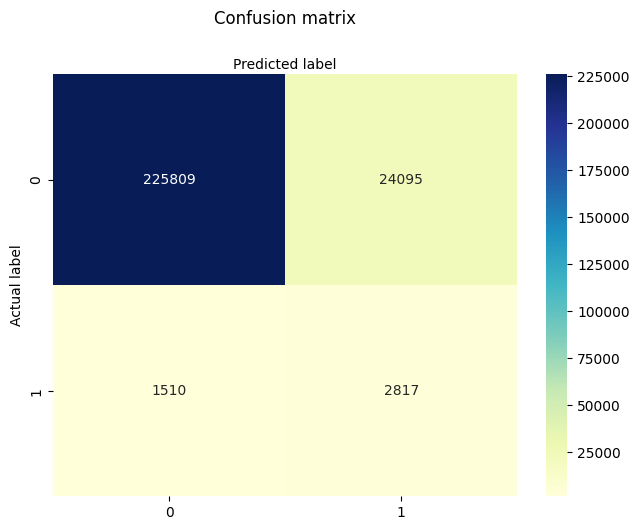

In [43]:
# Other metrics
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt


y_pred_test_class = catboost_model.predict(X_test)

# # Uncomment for applying threshold, can always tune after model run
# threshold = 0.25
# y_pred_test_class = (y_pred_test >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_test_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')


In [44]:
from sklearn.metrics import classification_report
target_names = ['without IP', 'with IP']
print(classification_report(y_test, y_pred_test_class, target_names=target_names))

              precision    recall  f1-score   support

  without IP       0.99      0.90      0.95    249904
     with IP       0.10      0.65      0.18      4327

    accuracy                           0.90    254231
   macro avg       0.55      0.78      0.56    254231
weighted avg       0.98      0.90      0.93    254231



In [45]:
# from sklearn.linear_model import LogisticRegression

# logreg = LogisticRegression(random_state=100)
# logreg.fit(X_train, y_train)

# y_pred_proba = logreg.predict_proba(X_test)[::,1]
# fpr, tpr, _ =roc_curve(y_test,  y_pred_proba)
# auc = roc_auc_score(y_test, y_pred_proba)
# plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
# plt.legend(loc=4)
# plt.show()

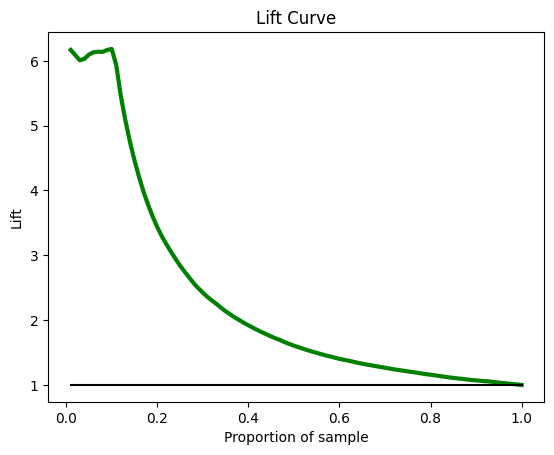

In [46]:
def plot_lift_curve(y_val, y_pred, step=0.01):
    
    #Define an auxiliar dataframe to plot the curve
    aux_lift = pd.DataFrame()
    #Create a real and predicted column for our new DataFrame and assign values
    aux_lift['real'] = y_val
    aux_lift['predicted'] = y_pred
    #Order the values for the predicted probability column:
    aux_lift.sort_values('predicted',ascending=False,inplace=True)
    
    #Create the values that will go into the X axis of our plot
    x_val = np.arange(step,1+step,step)
    #Calculate the ratio of ones in our data
    ratio_ones = aux_lift['real'].sum() / len(aux_lift)
    #Create an empty vector with the values that will go on the Y axis our our plot
    y_v = []
    
    #Calculate for each x value its correspondent y value
    for x in x_val:
        num_data = int(np.ceil(x*len(aux_lift))) #The ceil function returns the closest integer bigger than our number 
        data_here = aux_lift.iloc[:num_data,:]   # ie. np.ceil(1.4) = 2
        ratio_ones_here = data_here['real'].sum()/len(data_here)
        y_v.append(ratio_ones_here / ratio_ones)
           
   #Plot the figure
    fig, axis = plt.subplots()
    fig.figsize = (40,40)
    axis.plot(x_val, y_v, 'g-', linewidth = 3, markersize = 5)
    axis.plot(x_val, np.ones(len(x_val)), 'k-')
    axis.set_xlabel('Proportion of sample')
    axis.set_ylabel('Lift')
    plt.title('Lift Curve')
    plt.show()
    
plot_lift_curve(y_test, y_pred_test_class, step=0.01)

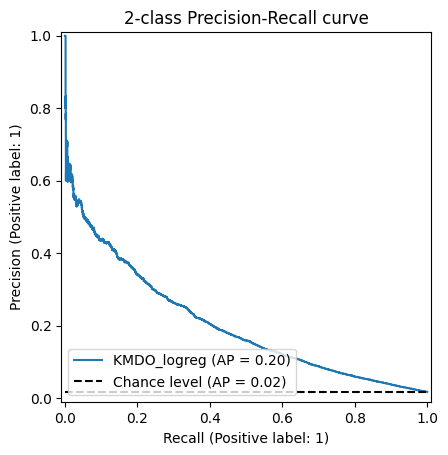

In [47]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    catboost_model, X_test, y_test, name="KMDO_logreg", plot_chance_level=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")

In [49]:
### PASTED OVER FROM GITHUB
def lift_chart(X,actual_target,model):
    avg_tgt = actual_target.sum()/len(actual_target)
    df_data = X.copy()
    X_data = df_data.copy()
    df_data['Actual'] = actual_target
    df_data['Predict']= model.predict(X_data)
    y_Prob = pd.DataFrame(model.predict_proba(X_data))
    df_data['Prob_1']=list(y_Prob[1])
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Percentile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Percentile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(actual_target))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df
lift_chart(X_test, y_test, catboost_model)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.995346,0.898151,866,2543,1.000271,20.013866,20.013866,1.000271,20.008436
1,0.898132,0.832520,458,2542,0.999878,10.584701,30.598567,2.000149,15.298140
2,0.832470,0.775923,321,2542,0.999878,7.418535,38.017102,3.000028,12.672251
3,0.775917,0.725332,246,2543,1.000271,5.685232,43.702334,4.000299,10.924767
4,0.725332,0.680882,206,2542,0.999878,4.760804,48.463138,5.000177,9.692285
...,...,...,...,...,...,...,...,...,...
95,0.037283,0.035850,5,2542,0.999878,0.115554,99.745782,95.999701,1.039022
96,0.035848,0.034292,1,2543,1.000271,0.023111,99.768893,96.999972,1.028546
97,0.034292,0.032462,5,2542,0.999878,0.115554,99.884446,97.999851,1.019231
98,0.032460,0.029969,3,2542,0.999878,0.069332,99.953779,98.999729,1.009637


In [36]:
# for col in string_columns:
#     X_train[col] = X_train[col].astype('category')
#     X_val[col] = X_val[col].astype('category')    
#     X_test[col] = X_test[col].astype('category')    

In [37]:
catboost_model_rfe = CatBoostClassifier(random_seed = 100,thread_count= 15, verbose=0)

rfecv = RFECV(
    estimator=catboost_model_rfe,
    step=10, # Num features removed for each step
    cv=KFold(2), # Num folds
    scoring="roc_auc",
    min_features_to_select=1,
    # n_jobs=2,
)

# with suppress_stdout_stderr():
rfecv.fit(X_train, y_train)

print(f"Optimal number of features: {rfecv.n_features_}")
# print(f"Feature rankings: {rfecv.ranking_}")


X_train_rfe = rfecv.transform(X_train) 
X_val_rfe = rfecv.transform(X_val) 
X_test_rfe = rfecv.transform(X_test)


KeyboardInterrupt



In [ ]:
import matplotlib.pyplot as plt

n_features = list(range(1, len(rfecv.cv_results_['mean_test_score']) + 1))
mean_test_scores = rfecv.cv_results_['mean_test_score']

cv_results = pd.DataFrame({
    'n_features': n_features,
    'mean_test_score': mean_test_scores
})

plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.plot(cv_results["n_features"], cv_results["mean_test_score"])
plt.title("Recursive Feature Elimination \nwith correlated features")
plt.show()

In [ ]:
# Catboost Post-RFE

valid_pool_rfe = Pool(X_val_rfe, y_val, cat_features=string_columns)
test_pool_rfe = Pool(X_test_rfe, y_test, cat_features=string_columns) 

catboost_model_rfe = CatBoostClassifier(random_seed = 100,thread_count= 15)
catboost_model_final.fit(X_train_rfe, y_train, eval_set=valid_pool_rfe, verbose=0, plot=False, cat_features=string_columns, use_best_model=True) 

y_pred_rfe = catboost_model_final.predict_proba(valid_pool_rfe)[:, 1]
lift_score_rfe = lift_at_1_percent(y_val, y_pred_rfe)
y_pred_2_rfe = catboost_model_final.predict_proba(test_pool_rfe)[:, 1] 
lift_score_2_rfe = lift_at_1_percent(y_test, y_pred_2_rfe) 


print(lift_score)
print(lift_score_2)
# print(lift_score_3)

In [ ]:
param =  {'iterations': 3072, 'depth': 6, 'learning_rate': 0.0153400505076495,
          'random_strength': 7, 'l2_leaf_reg': 6.67489746621405, 'border_count': 206,
          'min_data_in_leaf': 24, 'grow_policy': 'Lossguide', 'od_wait': 59, 
          'bootstrap_type': 'Bernoulli', 'subsample': 0.674856992438242,
          'max_leaves': 41,
          'random_seed':100,
          'leaf_estimation_iterations': 8,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'od_type': 'Iter',
        'thread_count':15}

# Instantiate the CatBoost model
catboost_model = CatBoostClassifier(**param)
catboost_model.fit(X_s,y, eval_set=valid_pool_s, verbose=0, plot=False,  cat_features=string_columns,  use_best_model=True)

catboost_model.save_model(f"catboost_fs_finetuned_ip6.cbm", format = "cbm" )

feature_importance = catboost_model.get_feature_importance().tolist()
feature_importance_df  = pd.DataFrame({"Name":X_s.columns.tolist(),"Importance": feature_importance}).sort_values("Importance",ascending = False)
#feature_importance_df.to_csv(f"Imp_fs_finetuned_ip6.csv",index =False)

# Calculate the lift score
y_pred = catboost_model.predict_proba(valid_pool_s)[:,1]
lift_score = lift_at_1_percent(y_val, y_pred)
#lift2_score = lift_at_2_percent(y_val, y_pred)

y_pred_2 = catboost_model.predict_proba(test_pool_s)[:,1]
lift_score_2 = lift_at_1_percent(y_test, y_pred_2)
#lift2_score_2 = lift_at_2_percent(y_test, y_pred_2)

y_pred_3 = catboost_model.predict_proba(test_pool_oot_s)[:,1]
lift_score_3 = lift_at_1_percent(y_test_oot, y_pred_3)
#lift2_score_3 = lift_at_2_percent(y_test_oot, y_pred_3)

print(lift_score)
print(lift_score_2)
print(lift_score_3)